In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
import pycountry
import geopandas as gpd
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import textwrap
import fiona

from src.text_processing_functions import *
from src.LLM_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *
from src.geocoding_utils import *
from src.hazard_def import *
from src.impact_def import *
from src.ImpactRegistry import Impacts
from src.impact_def import IMPACT_SUBTYPE_MERGER, IMPACT_SUBTYPES_MERGED

path_save_fig = DATA_FIGURE
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
print(spacy.__version__)
print(np.__version__)

3.8.7
2.3.3


In [8]:
# 200 reports 
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "post_processed_all_appeals_unique_1-333_meta-llama_llama-4-scout-17b-16e-instruct_v281025"
# res_name_llm = "post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# res_name_llm = "post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
res_name_llm = "merged_subtypes_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"

# df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), encoding='utf-8')
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), engine="fiona")
cols = [
    "appealCode", 
    "impactSubtype", 
    "impactValue", 
    "impactValueMin", 
    "impactValueMax", 
    "impactValuePrecision", 
    "impactUnit",
    "valueAnnotation", 
    "location", 
    "locationAnnotation", 
    "locationPolygon",
    "locationLowestAdmin",
    "iso3_code",
    "hazards", 
    "hazardsAnnotation",
    'startYear', 
    'startMonth', 
    'startDay', 
    'endYear', 
    'endMonth', 
    'endDay', 
    'dateAnnotation'
    # "flag_geocoding_country"
]

df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC/(res_name_llm+'.parquet'), columns=cols)

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "locationOsm", "locationPolygon", "iso3_code", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

num_cols = ["impactValue", "impactValueMin", "impactValueMax","startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]
list_cols = ["country","location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation", "annotation", "iso3_code"]
list_cols = [key for key in list_cols if key in df_llm_all_geo.columns]
df_llm_all_geo = format_output(df_llm_all_geo, num_cols=num_cols, list_cols=list_cols)

In [12]:
# Open the version with continents 
# res_name_llm = "filtered_post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v191225_Africa"
res_name_llm = "post_processed_labelled_reports_fixed_impact_desc2_meta-llama_llama-4-scout-17b-16e-instruct_v271025_v221225_geo"
df_llm_all_continent = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), engine="fiona")

In [13]:
df_llm_all_continent.head(5)

,appealCode,country,country_iso3,country_iso3_kw,country_kw,dateAnnotation,disasterType,endDay,endMonth,endYear,...,flag_percent,flag_remove_cat,flag_response_unit,locationLowestAdmin,flag_geocoding_country,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,geometry
0,MDRPK026,['Pakistan'],['PAK'],,,['Pakistan endured an exceptionally intense mo...,Flood,NaN,NaN,NaN,...,False,False,False,ADM_1,0,0,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']",['PAK'],"MULTIPOLYGON (((66.68991 24.91425, 66.96524 24..."
1,MDRPK026,['Pakistan'],['PAK'],,,['Pakistan endured an exceptionally intense mo...,Flood,NaN,NaN,NaN,...,False,False,False,ADM_0,1,0,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",['PAK'],"MULTIPOLYGON (((66.68991 24.91425, 66.96524 24..."
2,MDRPK026,['Pakistan'],['PAK'],,,['Pakistan endured an exceptionally intense mo...,Flood,NaN,8.0,2024.0,...,False,False,False,ADM_0,1,0,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa',...",['PAK'],"MULTIPOLYGON (((66.68991 24.91425, 66.96524 24..."
3,MDRPK026,['Pakistan'],['PAK'],,,['Pakistan endured an exceptionally intense mo...,Flood,NaN,NaN,NaN,...,False,False,False,ADM_2,0,1,"['Badin', 'Dadu', 'Jacobabad']","['Badin', 'Dadu', 'Jacobabad']",['PAK'],"MULTIPOLYGON (((68.76891 24.27327, 68.76228 24..."
4,MDRPK026,['Pakistan'],['PAK'],,,['Pakistan endured an exceptionally intense mo...,Flood,NaN,8.0,2024.0,...,False,False,False,ADM_1,0,0,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']","['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']",['PAK'],"MULTIPOLYGON (((66.68991 24.91425, 66.96524 24..."


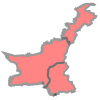

In [19]:
df_llm_all_continent.iloc[0]["geometry"]

In [14]:
df_llm_all_continent.to_parquet(
    DATA_OUT_PROC / (res_name_llm+"_wkb.parquet"),
    compression="zstd"
)

In [16]:
# Reopen the geomtries 
from shapely import wkb

df_open_back = pd.read_parquet(
    DATA_OUT_PROC / f"{res_name_llm}_wkb.parquet"
)

df_open_back["geometry"] = df_open_back["geometry"].apply(wkb.loads)

df_open_back = gpd.GeoDataFrame(
    df_open_back,
    geometry="geometry",
    crs="EPSG:4326"  # adjust if needed
)

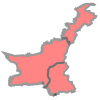

In [18]:
df_open_back.iloc[0]["geometry"]

In [21]:
df_llm_all_geo.loc[
    df_llm_all_geo["location"].apply(lambda x: isinstance(x, list) and "Kinshasa" in x),
    ["appealCode"]
]["appealCode"].unique()

array(['MDRCD016', 'MDRCD019', 'MDRCD024', 'MDRCD029', 'MDRCD039',
       'MDRCD042', 'MDRCD046'], dtype=object)

In [12]:
df_llm_all_geo.loc[df_llm_all_geo["locationLowestAdmin"]=="ADM_0"][["appealCode", "location"]]

,appealCode,location
0,1595,[]
1,1595,[]
3,1595,[]
4,1595,[]
5,1595,"[Mauritania, Benin, Togo, Chad, Central Africa..."
...,...,...
14804,MDRZW021,[]
14807,MDRZW021,"[Karonga, Rumphi, Mzimba North, Mzimba South, ..."
14808,MDRZW021,"[Blantyre, Karonga, Rumphi, Mzimba North, Mzim..."
14810,MDRZW021,"[Karonga, Rumphi, Mzimba North, Mzimba South, ..."


In [ ]:
# Combine Annotation columns

from itertools import chain
df_llm_all_geo_cp = cp.deepcopy(df_llm_all_geo)

columnsAnnotation = [
    "valueAnnotation",
    "locationAnnotation",
    "hazardsAnnotation",
    "dateAnnotation",
]

def combine_unique_sentences(row):
    seen = set()
    combined = []
    for sentence in chain.from_iterable(row[c] or [] for c in columnsAnnotation):
        if sentence not in seen:
            seen.add(sentence)
            combined.append(sentence)
    return combined

df_llm_all_geo_cp["sourceAnnotation"] = df_llm_all_geo_cp.apply(combine_unique_sentences, axis=1)

# Optionally drop the original columns
df_llm_all_geo_cp = df_llm_all_geo_cp.drop(columns=columnsAnnotation)

## Check the final data filter 

In [ ]:
## Script to filter final data
#1 drop duplicates
#2 select columns

import pandas as pd
import geopandas as gpd
from src.data import *
# from src.data_format import format_output, LIST_COLS
from src.post_process_functions import merge_annotations
from src.sanity_checks import gather_flags
from src.geocoding import atomic_gpkg_save
from src.geocoding_utils import split_continents
from src.logger_setup import set_logger

In [62]:
from src.data_format import *

In [63]:
LIST_COLS

['valueAnnotation',
 'country',
 'country_kw',
 'location',
 'hazards',
 'locationAnnotation',
 'dateAnnotation',
 'hazardsAnnotation',
 'annotation',
 'sourceExcerpts',
 'iso3_code',
 'nathaz_text',
 'locationOsm',
 'locationPolygon',
 'continent']

In [87]:
## Parameters
dedup_cols = ["appealCode","impactSubtype", "impactValue", "impactUnit", "country",
              "location", "startYear", "startMonth", "startDay","endYear", "endMonth",
              "endDay", "hazards"]
# dedup_cols = ["appealCode","impactSubtype", "impactValue", "impactUnit", "country",
#               "geometry", "startYear", "startMonth", "startDay","endYear", "endMonth",
#               "endDay", "hazards"]

##load data (model)
res_savename = "post_processed_labelled_reports_fixed_impact_desc_meta-llama_llama-4-scout-17b-16e-instruct_v271025_v221225_geo"
#"post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v191225"
#"post_processed_labelled_reports_fixed_impact_desc_meta-llama_llama-4-scout-17b-16e-instruct_v271025"
#"post_processed_new_unit_std_labelled_reports_impacts_all_v111025"
suffix = ""
res_savename_geo = res_savename + suffix
response_df = pd.read_csv(DATA_OUT_PROC / (res_savename + ".csv"))
response_df_geo = gpd.read_file(DATA_OUT_PROC / (res_savename_geo+".gpkg"))

# Reformat output 
response_df = format_output(response_df)
response_df_geo = format_output(response_df_geo)

for col in LIST_COLS : 
    if col in response_df.columns : 
        response_df[col] = response_df[col].apply(sorted)
    if col in response_df_geo.columns : 
        response_df_geo[col] = response_df_geo[col].apply(sorted)

response_df = delistify_cols(response_df)
response_df_geo = delistify_cols(response_df_geo)

filename_out = "filt_" + res_savename
filename_out_geo = "filt_" + res_savename_geo

#set up logger
logger_name = "data_filter"
log_file = DATA_LOGS / f"LOGS_{logger_name}_{filename_out}.txt"
LOGGER = set_logger(log_file, logger_name=logger_name)

In [88]:
response_df.loc[response_df["appealCode"]=="MDRCO023"][["impactSubtype", "impactValue", "impactUnit", "location"]]

,impactSubtype,impactValue,impactUnit,location
317,Affected People,57090.00000,people,"['Caldas', 'Cundinamarca', 'Quindio', 'Risaral..."
318,Targeted People,15314.00000,people,"['Caldas', 'Cundinamarca', 'Quindio', 'Risaral..."
319,DREF Allocation,517942.98841,EUR,"['Caldas', 'Cundinamarca', 'Quindio', 'Risaral..."
320,Human Health and Wellbeing,NaN,NaN,"['Caldas', 'Cundinamarca', 'Quindío', 'Risaral..."
321,"Water, Sanitation, and Hygiene",NaN,NaN,"['Caldas', 'Cundinamarca', 'Quindío', 'Risaral..."
...,...,...,...,...
384,Unknown,NaN,NaN,"['Caldas', 'Cundinamarca', 'Quindío', 'Risaral..."
385,Unknown,NaN,NaN,"['Caldas', 'Cundinamarca', 'Quindío', 'Risaral..."
386,Unknown,NaN,NaN,"['Caldas', 'Cundinamarca', 'Quindío', 'Risaral..."
387,Unknown,NaN,NaN,"['Caldas', 'Cundinamarca', 'Quindío', 'Risaral..."


In [89]:
## drop duplicates (needs to be done before formatting as lists dtypes cannot be dedup)
init_len = len(response_df)
init_len_geo = len(response_df_geo)
duplicates = response_df.duplicated(subset=dedup_cols)
duplicates_geo = response_df_geo.duplicated(subset=dedup_cols)
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
):
    LOGGER.info("Duplicates:\n %s", response_df.loc[duplicates, dedup_cols])#.to_string(max_rows=None, max_cols=None)
    LOGGER.info("Duplicates in geolocated data:\n %s", response_df_geo.loc[duplicates_geo, dedup_cols])#.to_string(max_rows=None, max_cols=None)

response_df = response_df[~duplicates]
response_df_geo = response_df_geo[~duplicates_geo]

LOGGER.info(f"Dropped {init_len - len(response_df)} duplicates")
LOGGER.info(f"Dropped {init_len_geo - len(response_df_geo)} duplicates in geolocated data")

Duplicates:
     appealCode                   impactSubtype  impactValue impactUnit  \
17    MDRPK026                      Healthcare          NaN        NaN   
39    MDRSD034                  Transportation          NaN        NaN   
73    MDRGE019                         Unknown          NaN        NaN   
75    MDRGE019                Displaced People          NaN        NaN   
76    MDRGE019                       Education          NaN        NaN   
107   MDRDZ011  Agriculture and Access to Food          NaN        NaN   
115   MDRDZ011     Power and Energy Production          NaN        NaN   
130   MDRCM039  Water, Sanitation, and Hygiene          NaN        NaN   
169   MDRNG041                  Transportation          NaN        NaN   
182   MDRRW022  Agriculture and Access to Food          NaN        NaN   
199   MDRRW022                         Unknown          NaN        NaN   
200   MDRRW022  Water, Sanitation, and Hygiene          NaN        NaN   
234   MDRUG050  Water, Sa

In [90]:
## Parse to correct dtypes
response_df = format_output(response_df)
response_df_geo = format_output(response_df_geo)

##Filter unwanted flags
unwanted_flags = ["flag_remove_cat", "flag_value_no_unit", "flag_unit_nonstd", "flag_response_unit", "flag_unknown_subtype"]
for flag in unwanted_flags:
    if flag not in response_df.columns:
        LOGGER.warning(f"Flag {flag} not found in data")
        continue
    if flag not in response_df_geo.columns:
        LOGGER.warning(f"Flag {flag} not found in geolocated data")
        continue
    init_len = len(response_df)
    init_len_geo = len(response_df_geo)
    response_df = response_df[response_df[flag]==False]
    response_df_geo = response_df_geo[response_df_geo[flag]==False]
    LOGGER.info(f"Filtered {init_len - len(response_df)} entries based on {flag} flag")
    LOGGER.info(f"Filtered {init_len_geo - len(response_df_geo)} entries based on {flag} flag in geolocated data")

Filtered 63 entries based on flag_remove_cat flag
Filtered 63 entries based on flag_remove_cat flag in geolocated data
Filtered 0 entries based on flag_value_no_unit flag
Filtered 0 entries based on flag_value_no_unit flag in geolocated data
Filtered 12 entries based on flag_unit_nonstd flag
Filtered 12 entries based on flag_unit_nonstd flag in geolocated data
Filtered 0 entries based on flag_response_unit flag
Filtered 0 entries based on flag_response_unit flag in geolocated data
Filtered 20 entries based on flag_unknown_subtype flag
Filtered 20 entries based on flag_unknown_subtype flag in geolocated data


In [91]:
response_df.head()

,appealCode,country,country_iso3,country_iso3_kw,country_kw,dateAnnotation,disasterType,endDay,endMonth,endYear,...,flag_percent,flag_remove_cat,flag_response_unit,locationLowestAdmin,flag_geocoding_country,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,flag_pop_cntry
0,MDRPK026,[Pakistan],['PAK'],NaN,[],[Pakistan endured an exceptionally intense mon...,Flood,NaN,NaN,NaN,...,False,False,False,ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh]","[Balochistan, Khyber Pakhtunkhwa, Sindh]",[PAK],False
1,MDRPK026,[Pakistan],['PAK'],NaN,[],[Pakistan endured an exceptionally intense mon...,Flood,NaN,8.0,2024.0,...,False,False,False,ADM_0,1,0,"[Balochistan, Gilgit-Baltistan, Khyber Pakhtun...","[Balochistan, Gilgit-Baltistan, Khyber Pakhtun...",[PAK],False
2,MDRPK026,[Pakistan],['PAK'],NaN,[],[Pakistan endured an exceptionally intense mon...,Flood,NaN,8.0,2024.0,...,False,False,False,ADM_0,1,0,"[Balochistan, Gilgit-Baltistan, Khyber Pakhtun...","[Balochistan, Gilgit-Baltistan, Khyber Pakhtun...",[PAK],False
3,MDRPK026,[Pakistan],['PAK'],NaN,[],"[In August 2024, rainfall increased by 137 per...",Flood,NaN,NaN,NaN,...,False,False,False,ADM_2,0,1,"[Badin, Dadu, Jacobabad]","[Badin, Dadu, Jacobabad]",[PAK],False
4,MDRPK026,[Pakistan],['PAK'],NaN,[],"[In August 2024, rainfall increased by 137 per...",Flood,NaN,8.0,2024.0,...,False,False,False,ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh]","[Balochistan, Khyber Pakhtunkhwa, Sindh]",[PAK],False


In [92]:
## gather flag columns
flag_unit_std = ['flag_unit_harmonization', 'flag_non-SI_unit_standardization']
flag_error_columns = ["flag_remove_number_unit_error",
                      "flag_unit_conversion_error",
                      "flag_non-SI_unit_standardization_error",
                      "flag_SI_unit_standardization_error",
                      'flag_failed_currency_conversion']

response_df = gather_flags(response_df, flag_unit_std, flag_name="flag_non-SI_unit_standardization")
response_df_geo = gather_flags(response_df_geo, flag_unit_std, flag_name="flag_non-SI_unit_standardization")
response_df = gather_flags(response_df, flag_error_columns, flag_name="flag_unit_processing_error")
response_df_geo = gather_flags(response_df_geo, flag_error_columns, flag_name="flag_unit_processing_error")

In [93]:
## gather annotation columns
annotation_columns = ["valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
response_df["sourceExcerpts"] = response_df.apply(merge_annotations, args=(annotation_columns,), axis=1)
response_df_geo["sourceExcerpts"] = response_df_geo.apply(merge_annotations, args=(annotation_columns,), axis=1)

In [94]:
response_df[annotation_columns+["sourceExcerpts"]]

,valueAnnotation,locationAnnotation,dateAnnotation,hazardsAnnotation,sourceExcerpts
0,"[People Affected: 326,788 people]","[In August 2024, rainfall increased by 137 per...",[Pakistan endured an exceptionally intense mon...,"[In August 2024, rainfall increased by 137 per...","[People Affected: 326,788 people, In August 20..."
1,[The monsoon season caused 306 fatalities and ...,[Pakistan endured an exceptionally intense mon...,[Pakistan endured an exceptionally intense mon...,"[In August 2024, rainfall increased by 137 per...",[The monsoon season caused 306 fatalities and ...
2,[The monsoon season caused 306 fatalities and ...,[Pakistan endured an exceptionally intense mon...,[Pakistan endured an exceptionally intense mon...,"[In August 2024, rainfall increased by 137 per...",[The monsoon season caused 306 fatalities and ...
3,"[Sindh experienced acute urban flooding, parti...","[Sindh experienced acute urban flooding, parti...","[In August 2024, rainfall increased by 137 per...","[In August 2024, rainfall increased by 137 per...","[Sindh experienced acute urban flooding, parti..."
4,[The major donors and partners of the IFRC-DRE...,"[In Balochistan, floods affected more than 17,...","[In August 2024, rainfall increased by 137 per...","[In August 2024, rainfall increased by 137 per...",[The major donors and partners of the IFRC-DRE...
...,...,...,...,...,...
484,[PRC identified emergency needs based on rapid...,"[The three hardest hit areas were Aurora, Cata...","[By morning of 17 October, Typhoon Sarika had ...","[On 16 October 2016, at 2:30 AM, Typhoon Sarik...",[PRC identified emergency needs based on rapid...
487,"[According to government data, 12,777 houses w...","[According to government data, 12,777 houses w...","[By morning of 17 October, Typhoon Sarika had ...","[On 16 October 2016, at 2:30 AM, Typhoon Sarik...","[According to government data, 12,777 houses w..."
488,"[According to government data, 12,777 houses w...","[According to government data, 12,777 houses w...","[By morning of 17 October, Typhoon Sarika had ...","[On 16 October 2016, at 2:30 AM, Typhoon Sarik...","[According to government data, 12,777 houses w..."
489,[Number of people affected: up to approximatel...,[Number of people affected: up to approximatel...,[Number of people affected: up to approximatel...,"[On 21 June 2016, heavy rain and hailstorm hit...",[Number of people affected: up to approximatel...


In [95]:
## Filter unwanted columns
columns_data_final = ["appealCode", "reportDate", "reportLink", "disasterType",
                 "impactSubtype", "impactValue", "impactValueMin", "impactValueMax", "impactValuePrecision", "impactUnit",
                 "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay", "hazards", "location",
                 "locationPolygon", "locationLowestAdmin", "iso3_code", "sourceExcerpts"]

columns_flags_final = ['valid_errors_impactValue',
         'valid_errors_loc',
         'valid_errors_dates',
         'valid_errors_haz',
        #  'flag_value_not_in_text',
         'flag_impactSubtype_reclass',
         'flag_hazards_reclass',
         'flag_remove_number_unit',
         'flag_SI_unit_standardization',
         'flag_non-SI_unit_standardization',
         'flag_unit_processing_error',
         'flag_unit_nonstd',
         'flag_reclass_subtype_from_unit',
        #  'flag_pop_cntry',
         'flag_value_no_unit',
         'flag_partial_unit',
         'flag_geocoding_country',
         'flag_geocoding_osm']

response_df_filtered = response_df.copy()
response_df_filtered = response_df_filtered[columns_data_final + columns_flags_final]
response_df_geo_filtered = response_df_geo.copy()
response_df_geo_filtered = response_df_geo_filtered[columns_data_final + ["geometry"] + columns_flags_final]

## Rename cols
col_rename = {
    "iso3_code": "country_iso3",
    "disasterType": "disasterType_IFRC"
}
response_df_geo_filtered = response_df_geo_filtered.rename(columns=col_rename)
response_df_filtered = response_df_filtered.rename(columns=col_rename)

In [98]:
response_df_filtered

,appealCode,reportDate,reportLink,disasterType_IFRC,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,...,flag_remove_number_unit,flag_SI_unit_standardization,flag_non-SI_unit_standardization,flag_unit_processing_error,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_value_no_unit,flag_partial_unit,flag_geocoding_country,flag_geocoding_osm
0,MDRPK026,2025-03-28,https://go-api.ifrc.org/api/downloadfile/88815...,Flood,Affected People,326788.0,NaN,NaN,exact,people,...,False,False,True,False,False,False,False,False,0,0
1,MDRPK026,2025-03-28,https://go-api.ifrc.org/api/downloadfile/88815...,Flood,Injured People,584.0,NaN,NaN,exact,people,...,False,False,True,False,False,False,False,False,1,0
2,MDRPK026,2025-03-28,https://go-api.ifrc.org/api/downloadfile/88815...,Flood,Human Deaths,306.0,NaN,NaN,exact,people,...,False,False,True,False,False,False,False,False,1,0
3,MDRPK026,2025-03-28,https://go-api.ifrc.org/api/downloadfile/88815...,Flood,Displaced People,9500.0,NaN,NaN,exact,people,...,False,False,True,False,False,False,False,False,0,1
4,MDRPK026,2025-03-28,https://go-api.ifrc.org/api/downloadfile/88815...,Flood,Residential Buildings,15000.0,NaN,NaN,exact,homes,...,False,False,True,False,False,True,False,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,MDRPH021,2017-05-31,https://adore.ifrc.org/Download.aspx?FileId=16...,Cyclone,"Water, Sanitation, and Hygiene",NaN,NaN,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,0,0
487,MDRPH021,2017-05-31,https://adore.ifrc.org/Download.aspx?FileId=16...,Cyclone,Residential Buildings,11356.0,NaN,NaN,exact,homes,...,False,False,True,False,False,False,False,False,0,0
488,MDRPH021,2017-05-31,https://adore.ifrc.org/Download.aspx?FileId=16...,Cyclone,Residential Buildings,1421.0,NaN,NaN,exact,homes,...,False,False,True,False,False,False,False,False,0,0
489,MDRHU005,2016-11-29,https://adore.ifrc.org/Download.aspx?FileId=15...,Cyclone,Affected People,2282.0,NaN,NaN,exact,people,...,False,False,True,False,False,False,False,False,1,0


In [97]:
## Save
atomic_gpkg_save(response_df_geo_filtered, DATA_OUT_PROC / (filename_out_geo + ".gpkg"))
response_df_geo_filtered.to_parquet(DATA_OUT_PROC / (filename_out_geo+".parquet"),compression="zstd", index=False)
# response_df_filtered.to_parquet(DATA_OUT_PROC / (filename_out + ".parquet"), index=False)
response_df_filtered.to_csv(DATA_OUT_PROC / (filename_out + ".csv"), index=False)

## Split per continent
world = gpd.read_file(ADMIN_PATH / "ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
#need to be formated to list
response_df_geo_filtered_continent = split_continents(response_df_geo_filtered, world)
for continent, df in response_df_geo_filtered_continent.items():
    print(continent, type(continent))
    continent = continent.replace(" ", "_")
    atomic_gpkg_save(df, DATA_OUT_PROC / (f"{filename_out_geo}_{continent}" + ".gpkg"))
    print(len(str(DATA_OUT_PROC / f"{filename_out_geo}_{continent}.parquet")))
    df.to_parquet(DATA_OUT_PROC / (f"{filename_out_geo}_{continent}"+".parquet"),compression="zstd", index=False)

Africa <class 'str'>
251
Asia <class 'str'>
249
Europe <class 'str'>
251
North America <class 'str'>
258
South America <class 'str'>
258
